In [1]:
import numpy as np
import pandas as pd

idle_csv = pd.read_csv('idle_var.csv')

<AxesSubplot:>

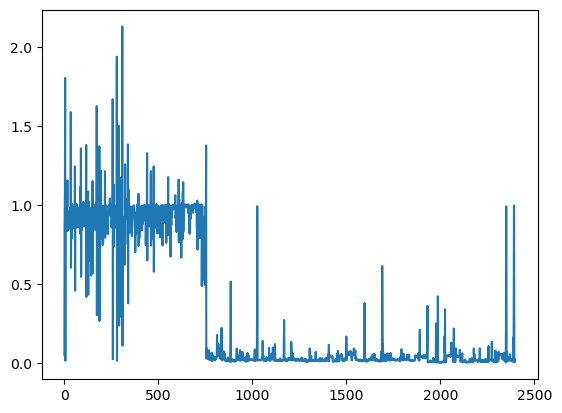

In [2]:
idle_csv
util = idle_csv['cycle-count:10'] / (idle_csv['Freq(kHz):10'] * idle_csv['Duration(ms)'])
upi = idle_csv['uops_executed.core:11'] / idle_csv['instructions:11']
util.plot()

<AxesSubplot:>

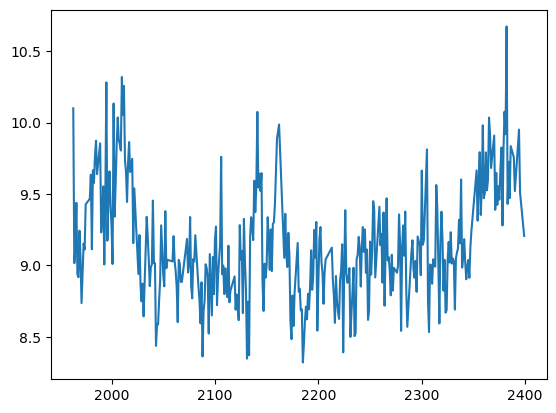

In [3]:
def filter_idle(df):
    df['avgutil'] = pd.Series(0.0, index=df.index)
    for core in range(20):
        df['avgutil'] += idle_csv['cycle-count:'+str(core)] / (idle_csv['Freq(kHz):'+str(core)])
    df['avgutil'] = df['avgutil']/(20 * df['Duration(ms)'])
    #df['avgutil'].plot()
    return df[df['avgutil'] < 0.02]
idle_df = filter_idle(idle_csv)
idle_df['Package Power(W):0'].plot()
#idle_df['Temp(C):0'].plot()


In [4]:
from PPEPDataset import PPEPRecord

idle_record = PPEPRecord(idle_df)

<AxesSubplot:>

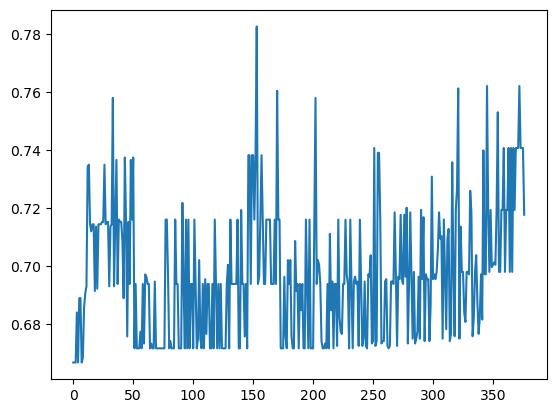

In [5]:
pd.Series(idle_record.coredata[:,0,0,0]).plot()

<AxesSubplot:xlabel='Freq(kHz):0', ylabel='Voltage:0'>

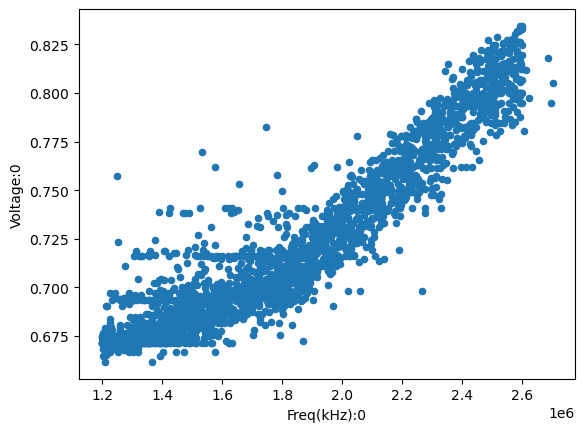

In [6]:

idle_csv.plot.scatter('Freq(kHz):0', 'Voltage:0')

/var/folders/4v/cdy84c810wg_t6bs65kjv7sw0000gn/T/ipykernel_77308/1258293474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idle_df['Vavg:0'] = 0.0
/var/folders/4v/cdy84c810wg_t6bs65kjv7sw0000gn/T/ipykernel_77308/1258293474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idle_df['Vavg:0'] = idle_df['Vavg:0'] + idle_df['Voltage:'+str(i)] / 10
/var/folders/4v/cdy84c810wg_t6bs65kjv7sw0000gn/T/ipykernel_77308/1258293474.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

<AxesSubplot:xlabel='Vavg:1', ylabel='Package Power(W):1'>

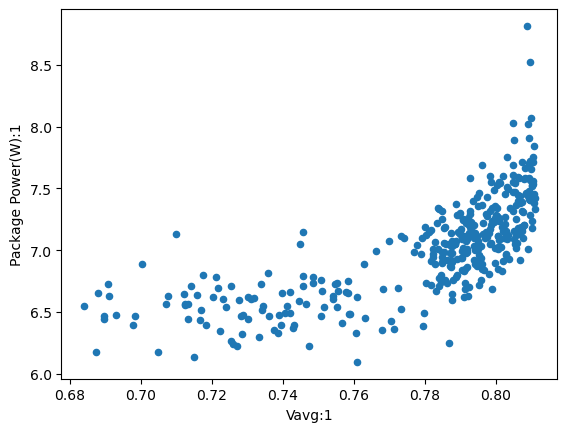

In [7]:
idle_df['Vavg:0'] = 0.0

for i in range(0,10):
    idle_df['Vavg:0'] = idle_df['Vavg:0'] + idle_df['Voltage:'+str(i)] / 10

idle_df['Vavg:1'] = 0.0

for i in range(10,20):
    idle_df['Vavg:1'] = idle_df['Vavg:1'] + idle_df['Voltage:'+str(i)] / 10

idle_df.plot.scatter('Vavg:1', 'Package Power(W):1')

/Users/hwnam/miniforge3/envs/torch/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


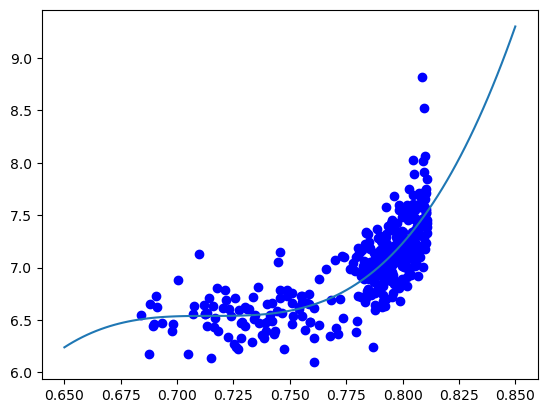

      3        2
1111 x - 2383 x + 1703 x - 399


In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression 

x = idle_df['Vavg:1'].to_numpy()
y = idle_df['Package Power(W):1'].to_numpy()

mymodel = np.poly1d(np.polyfit(x, y, 3))
myline = np.linspace(0.65, 0.85, 100)


plt.scatter(x, y, color='blue')
plt.plot(myline, mymodel(myline))
plt.show()
print(mymodel)

with open('idlemodel.txt', 'w') as imodel:
    for c in mymodel.coef:
        imodel.write(str(c) + '\n')


/var/folders/4v/cdy84c810wg_t6bs65kjv7sw0000gn/T/ipykernel_77308/3982502380.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idle_df['Tavg:1'] = 0.0
/var/folders/4v/cdy84c810wg_t6bs65kjv7sw0000gn/T/ipykernel_77308/3982502380.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idle_df['Tavg:1'] = idle_df['Tavg:1'] + idle_df['Temp(C):'+str(i)] / 10.0


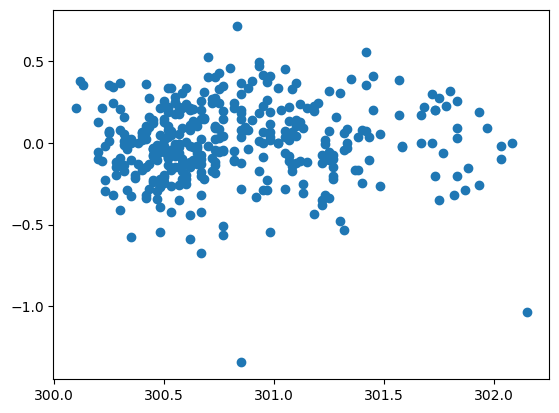

In [9]:
tempdiff = (mymodel(x) - y)

idle_df['Tavg:1'] = 0.0

for i in range(10,20):
    idle_df['Tavg:1'] = idle_df['Tavg:1'] + idle_df['Temp(C):'+str(i)] / 10.0

ptmp = idle_df['Tavg:1'].to_numpy() + 273

plt.scatter(ptmp,tempdiff)



[ 0.05677019 -0.11224442  0.72862957]
         2
0.05677 x - 0.1122 x + 0.7286
[1.         1.02020202 1.04040404 1.06060606 1.08080808 1.1010101
 1.12121212 1.14141414 1.16161616 1.18181818 1.2020202  1.22222222
 1.24242424 1.26262626 1.28282828 1.3030303  1.32323232 1.34343434
 1.36363636 1.38383838 1.4040404  1.42424242 1.44444444 1.46464646
 1.48484848 1.50505051 1.52525253 1.54545455 1.56565657 1.58585859
 1.60606061 1.62626263 1.64646465 1.66666667 1.68686869 1.70707071
 1.72727273 1.74747475 1.76767677 1.78787879 1.80808081 1.82828283
 1.84848485 1.86868687 1.88888889 1.90909091 1.92929293 1.94949495
 1.96969697 1.98989899 2.01010101 2.03030303 2.05050505 2.07070707
 2.09090909 2.11111111 2.13131313 2.15151515 2.17171717 2.19191919
 2.21212121 2.23232323 2.25252525 2.27272727 2.29292929 2.31313131
 2.33333333 2.35353535 2.37373737 2.39393939 2.41414141 2.43434343
 2.45454545 2.47474747 2.49494949 2.51515152 2.53535354 2.55555556
 2.57575758 2.5959596  2.61616162 2.63636364 2.6565

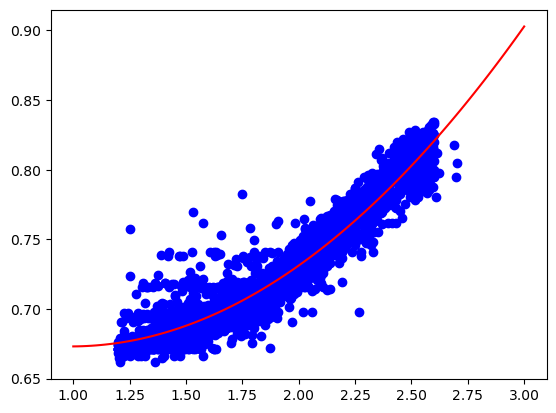

In [10]:
turbo_csv = pd.read_csv('gnn_tts_turbo.csv')

freq0 = idle_csv['Freq(kHz):0'].to_numpy()*1e-6
volt0 = idle_csv['Voltage:0'].to_numpy()
coef = np.polyfit(freq0, volt0, 2)
poly1d_fn = np.poly1d(coef) 
myline = np.linspace(1.0, 3.0, 100)
print(coef)
print(poly1d_fn)
print(myline)

freqt = turbo_csv['Freq(kHz):0'].to_numpy()
voltt = turbo_csv['Voltage:0'].to_numpy()

plt.scatter(freq0, volt0, color='blue')
#plt.scatter(freq0, poly1d_fn(freq0), color='red')
plt.plot(myline, poly1d_fn(myline), color='red')
plt.show()
with open('vfpoly.txt', 'w') as vfpoly:
    for c in coef:
        vfpoly.write(str(c) + '\n')



In [11]:
gnn_tts = pd.read_csv('gnn_tts_2600.csv')
gtrecord = PPEPRecord(gnn_tts)
print(gtrecord.coredata.shape)
print(gtrecord.corestat.shape)
print(gtrecord.pkgdata.shape)
pkgctrdata = gtrecord.coredata.sum(axis=2)
pkgstatdata = gtrecord.corestat.mean(axis=2)
print(gtrecord.counters)
print(gtrecord.stats)
print(pkgctrdata.shape)
print(pkgstatdata.shape)
pkgstatdata[:,:,3] *= 10 # bips is sum
pkgctrdata[:,:,0] *= 0.1 # voltage is average
pkgctrdata[:,:,1] *= 1e-7 # Freq is average and convert to ghz
pkgctrdata[:,:,2] *= 0.1 # Temp is average

volt = pd.Series(pkgctrdata[:,0, 0])
freq = pd.Series(pkgctrdata[:,0, 1])
st = pd.Series(pkgstatdata[:,1, 2])
#volt.plot()
#freq.plot()
#st.plot()

(2400, 2, 10, 9)
(2400, 2, 10, 7)
(2400, 2, 2)
['Voltage', 'Freq(kHz)', 'Temp(C)', 'instructions', 'cycle-count', 'cycle_activity.stalls_ldm_pending', 'uops_executed.core', 'branch-misses', 'cache-misses']
['Util', 'MCPI', 'CCPI', 'BIPS', 'uop/inst', 'bmiss/inst', 'cmiss/inst']
(2400, 2, 9)
(2400, 2, 7)


In [12]:
pkgpower = gtrecord.pkgdata[:,:,1]
#pd.Series(pkgpower[:,1]).plot()
pkgvolt = pkgctrdata[:,:, 0]
pkgbips = pkgstatdata[:,:,3]
pkgutil = pkgstatdata[:,:,0]
pkgbcps = pkgutil * pkgctrdata[:,:,1]
pkgstats = pkgstatdata[:,:,4:] * pkgbips[:,:,None]
pkgstats = np.concatenate([pkgstats, pkgbips[:,:,None], pkgbcps[:,:,None]], axis=-1)

In [13]:
from sklearn import linear_model
from PPEPDataset import PPEPData

#mydata = PPEPData(['llama_stablediffusion_2600.csv', 'gnn_tts_2600.csv'])
trainlist = ['data/blackscholes_bodytrack_2600.csv', 'data/splash2x.lu_ncp_splash2x.lu_cb_2600.csv',
             'data/canneal_facesim_2600.csv', 'data/splash2x.ocean_cp_splash2x.ocean_ncp_2600.csv',
             'data/fluidanimate_freqmine_2600.csv', 'data/splash2x.volrend_splash2x.raytrace_2600.csv',
             'data/raytrace_streamcluster_2600.csv', 'data/splash2x.water_spatial_splash2x.water_nsquared_2600.csv',
             'data/splash2.barnes_splash2.cholesky_2600.csv', 'data/vips_swaptions_2600.csv',
             'data/splash2.fft_splash2.fmm_2600.csv', 'llama_stablediffusion_2600.csv', 'gnn_tts_2600.csv'
             ]
mydata = PPEPData(trainlist)
active_model = linear_model.LinearRegression()
pkgvoltsquare = mydata.voltages * mydata.voltages
linearbase = (mydata.voltages + pkgvoltsquare)[:,None] * mydata.pstats
pkgidle = mydata.idlemodel(mydata.voltages)
pkgactive = mydata.power - pkgidle
active_model.fit(linearbase, pkgactive)
print(active_model.coef_)
with open('activecoef.txt', 'w') as acoef:
    for c in active_model.coef_:
        acoef.write(str(c) + '\n')


      3        2
1111 x - 2383 x + 1703 x - 399
         2
0.05677 x - 0.1122 x + 0.7286
[ -0.13338293 -29.67821709  13.11744306   0.35484382   8.22560349]


4.623722418680329


43.66029616738775

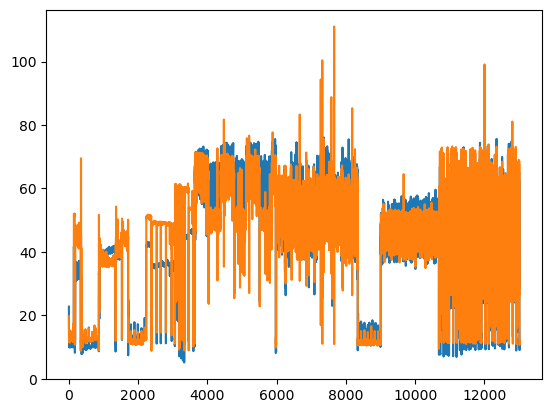

In [14]:
'''
validdata = PPEPData(['llama_stablediffusion_2600.csv', 'gnn_tts_2600.csv'])
pkgvoltsquare = validdata.voltages * validdata.voltages
linearbase = (validdata.voltages + pkgvoltsquare)[:,None] * validdata.pstats
pkgidle = validdata.idlemodel(validdata.voltages)
pkgactive = validdata.power - pkgidle
'''


pd.Series(pkgactive).plot()
apred = active_model.predict(linearbase)
pd.Series(apred).plot()
aae = np.abs(pkgactive - apred)
print(aae.mean())
pkgactive.mean()


## TODO

- use multiple data, append pkg data
- validate on variable freq
- determine alpha

      3        2
1111 x - 2383 x + 1703 x - 399
         2
0.05677 x - 0.1122 x + 0.7286


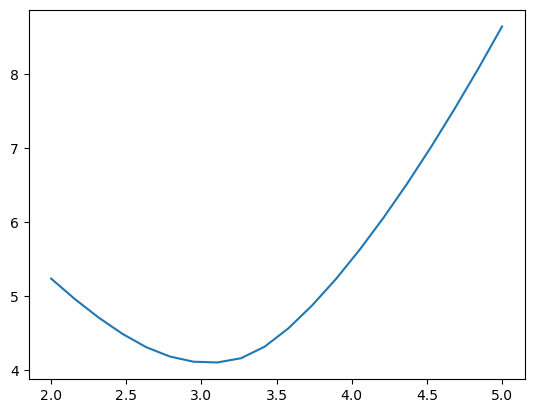

In [15]:
validdata = PPEPData(['gnn_tts_var.csv','gnn_tts_turbo.csv', 'llama_stablediffusion_var.csv', 'llama_stablediffusion_turbo.csv'])

aaes = []

for alpha in np.linspace(2,8,20):
    pkgvoltsquare = validdata.voltages ** alpha / (0.8 ** (alpha-2))
    linearbase = (validdata.voltages + pkgvoltsquare)[:,None] * validdata.pstats
    pkgidle = validdata.idlemodel(validdata.voltages)
    pkgactive = validdata.power - pkgidle
    apred = active_model.predict(linearbase)
    aae = np.abs(pkgactive - apred)
    aaes.append(aae.mean())
plt.plot(np.linspace(2,5,20), aaes)






4.401025226651272


53.804457954988465

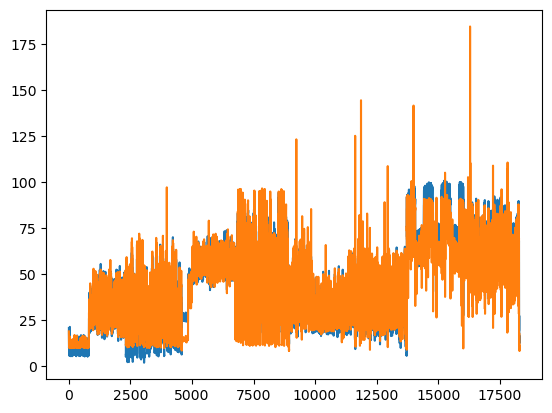

In [18]:
myalpha = 3.1
pkgvoltsquare = validdata.voltages ** myalpha / (0.8 ** (myalpha-2))
linearbase = (validdata.voltages + pkgvoltsquare)[:,None] * validdata.pstats
pkgidle = validdata.idlemodel(validdata.voltages)
pkgactive = validdata.power - pkgidle
apred = active_model.predict(linearbase)
aae = np.abs(pkgactive - apred)
pd.Series(pkgactive).plot()
apred = active_model.predict(linearbase)
pd.Series(apred).plot()
aae = np.abs(pkgactive - apred)
print(aae.mean())
validdata.power.mean()

In [17]:
print(pkgactive[aae.argmax()])
print(aae.argmax())
print(pkgactive[aae.argmax()] + pkgidle[aae.argmax()])

75.5827308939663
16295
90.248037915711
